# Прогноз пассажиропотока трамвая, ноябрь-декабрь 2025

Метрика: `WAPE = sum|y - y_hat| / sum(y)`, скор `max(0, 1 - WAPE)`, считается глобально
по всей сетке `route x date x hour`.

Порядок работы: загрузка плотной сетки -> метрики -> опорная модель на одном сплите ->
бэктест с реальным горизонтом 61 день -> подбор гиперпараметров -> финальная модель -> submission.

## 1. Данные

In [1]:
import numpy as np
import polars as pl
import pandas as pd
import catboost as cb

import plotly.express as px
import matplotlib.pyplot as plt

from datetime import date

from data_preparation import load_calendar, load_dataset, enrich_features, build_submit

from metrics import wape, wape_score, wape_report
from backtest import make_folds, cv_score, fit_calibration, apply_calibration

In [2]:
ROUTES: tuple[int, ...] = (1, 5, 7, 11, 12, 17, 25, 26, 28, 50)

calendar = load_calendar("input/calendar/2025.xml")

train_df = load_dataset("dataset/train.csv", start_date=date(2025, 1, 1), end_date=date(2025, 8, 31), routes=ROUTES)
train_df = enrich_features(train_df, calendar)
display(train_df.head(5))

test_df = load_dataset("dataset/test.csv", start_date=date(2025, 9, 1), end_date=date(2025, 10, 31), routes=ROUTES)
test_df = enrich_features(test_df, calendar)
display(test_df.head(5))

submit_df = build_submit(routes=ROUTES)
submit_df = enrich_features(submit_df, calendar)
display(submit_df.head(5))

date,hour,route,target,is_holiday,is_weekend,is_short_working_day,season,date_str,weekday,day_of_month,day_of_year
date,i8,i32,i32,bool,bool,bool,str,str,i8,i8,i16
2025-01-01,0,1,0,true,true,false,"""winter""","""2025-01-01""",3,1,1
2025-01-01,0,5,0,true,true,false,"""winter""","""2025-01-01""",3,1,1
2025-01-01,0,7,0,true,true,false,"""winter""","""2025-01-01""",3,1,1
2025-01-01,0,11,0,true,true,false,"""winter""","""2025-01-01""",3,1,1
2025-01-01,0,12,0,true,true,false,"""winter""","""2025-01-01""",3,1,1


date,hour,route,target,is_holiday,is_weekend,is_short_working_day,season,date_str,weekday,day_of_month,day_of_year
date,i8,i32,i32,bool,bool,bool,str,str,i8,i8,i16
2025-09-01,0,1,0,false,false,false,"""autumn""","""2025-09-01""",1,1,244
2025-09-01,0,5,0,false,false,false,"""autumn""","""2025-09-01""",1,1,244
2025-09-01,0,7,0,false,false,false,"""autumn""","""2025-09-01""",1,1,244
2025-09-01,0,11,0,false,false,false,"""autumn""","""2025-09-01""",1,1,244
2025-09-01,0,12,0,false,false,false,"""autumn""","""2025-09-01""",1,1,244


date,hour,route,is_holiday,is_weekend,is_short_working_day,season,date_str,weekday,day_of_month,day_of_year
date,i8,i32,bool,bool,bool,str,str,i8,i8,i16
2025-11-01,0,1,false,false,true,"""autumn""","""2025-11-01""",6,1,305
2025-11-01,0,5,false,false,true,"""autumn""","""2025-11-01""",6,1,305
2025-11-01,0,7,false,false,true,"""autumn""","""2025-11-01""",6,1,305
2025-11-01,0,11,false,false,true,"""autumn""","""2025-11-01""",6,1,305
2025-11-01,0,12,false,false,true,"""autumn""","""2025-11-01""",6,1,305


In [3]:
# проверки загруженных данных: полная сетка без пропусков
for name, df, days in (("train", train_df, 243), ("test", test_df, 61), ("submit", submit_df, 61)):
    expected = days * 24 * len(ROUTES)
    assert df.height == expected, f"{name}: ожидалось {expected} строк, получено {df.height}"
    print(f"{name:>6}: {df.height:>6} строк, {df['date'].min()} - {df['date'].max()}")

# пары route x hour, где посадок не бывает никогда: их прогноз принудительно нулевой.
# маршрут 5 попадает сюда целиком - в истории по нему ноль успешных валидаций,
# при этом в submission он обязан присутствовать (10 маршрутов x 61 день x 24 часа)
dead_keys = (
    pl.concat([
        train_df.select(["route", "hour", "target"]),
        test_df.select(["route", "hour", "target"]),
    ])
    .group_by(["route", "hour"])
    .agg(pl.col("target").sum().alias("total"))
    .filter(pl.col("total") == 0)
    .select(["route", "hour"])
)

print(f"\nмёртвых пар route x hour: {dead_keys.height}")
display(
    dead_keys
    .group_by("route")
    .agg(pl.col("hour").sort().alias("hours"), pl.len().alias("n"))
    .sort("route")
)

# нули существуют только благодаря плотной сетке: при group_by по сырым данным таких строк нет
print(f"доля нулевых строк в train: {train_df.filter(pl.col('target') == 0).height / train_df.height:.1%}")

 train:  58320 строк, 2025-01-01 - 2025-08-31
  test:  14640 строк, 2025-09-01 - 2025-10-31
submit:  14640 строк, 2025-11-01 - 2025-12-31

мёртвых пар route x hour: 26


route,hours,n
i32,list[i8],u32
5,"[0, 1, … 23]",24
25,"[2, 3]",2


доля нулевых строк в train: 20.7%


## 2. Разведка

In [4]:
plot_df = (
    train_df
    .with_columns(
        pl.concat_str([
            pl.col("date"),
            pl.lit(" "),
            pl.col("hour").cast(pl.String).str.zfill(2),
            pl.lit(":00"),
        ])
        .str.strptime(
            pl.Datetime,
            format="%Y-%m-%d %H:%M",
            strict=True,
        )
        .alias("datetime"),

        pl.col("route").cast(pl.String),
    )
    .sort(["route", "datetime"])
)

fig = px.line(
    plot_df,
    x="datetime",
    y="target",
    color="route",
)

fig.update_xaxes(
    type="date",
    tickformat="%d %b<br>%H:%M",
    hoverformat="%Y-%m-%d %H:%M",
)

fig.show()

In [5]:
fig = px.line(
    plot_df.filter(pl.col('hour') == 12),
    x="datetime",
    y="target",
    color="route",
)

fig.update_xaxes(
    type="date",
    tickformat="%d %b<br>%H:%M",
    hoverformat="%Y-%m-%d %H:%M",
)

fig.show()

## 3. Метрика

In [6]:
# метрики переехали в metrics.py, чтобы все три ноутбука считали одинаково.
# wape - одна глобальная дробь, как на лидерборде; wape_report - разбивка по группам,
# где wape_contrib показывает вклад группы в глобальную метрику
help(wape_report)

## 4. Опорная модель

Один сплит: обучение янв-июл, валидация август, честная оценка на сен-окт.
Нужна как точка отсчёта и как быстрая проверка, что данные и фичи не сломаны.
Финальная модель собирается ниже, по результатам бэктеста.

In [7]:
features = [
    "hour",
    "route",
    "is_holiday",
    "is_weekend",
    "is_short_working_day",
    "season",
    "weekday",
    "day_of_month",
    "day_of_year",
]

cat_features = [
    "route",
    "is_holiday",
    "is_weekend",
    "is_short_working_day",
    "season",
    "weekday",
]

train_part = (
    train_df
    .filter(pl.col("date") < pl.date(2025, 8, 1))
    .sort(["date", "hour", "route"])
    .to_pandas()
)

valid_part = (
    train_df
    .filter(pl.col("date") >= pl.date(2025, 8, 1))
    .sort(["date", "hour", "route"])
    .to_pandas()
)

test_part = test_df.to_pandas()

X_train = train_part[features]
y_train = train_part['target']

X_valid = valid_part[features]
y_valid = valid_part['target']

X_test = test_part[features]
y_test = test_part['target']

print(f"Train shape: {X_train.shape}, dates: {train_part['date'].min()} - {train_part['date'].max()}")
print(f"Valid shape: {X_valid.shape}, dates: {valid_part['date'].min()} - {valid_part['date'].max()}")
print(f"Test shape: {X_test.shape}, dates: {test_part['date'].min()} - {test_part['date'].max()}")

Train shape: (50880, 9), dates: 2025-01-01 00:00:00 - 2025-07-31 00:00:00
Valid shape: (7440, 9), dates: 2025-08-01 00:00:00 - 2025-08-31 00:00:00
Test shape: (14640, 9), dates: 2025-09-01 00:00:00 - 2025-10-31 00:00:00


0:	learn: 689.7356930	test: 592.4830814	best: 592.4830814 (0)	total: 74.2ms	remaining: 3m 42s
100:	learn: 199.9117713	test: 180.9018091	best: 180.9018091 (100)	total: 1.26s	remaining: 36.2s
200:	learn: 181.9851774	test: 168.5171131	best: 168.5171131 (200)	total: 2.23s	remaining: 31s
300:	learn: 175.3324192	test: 163.9487811	best: 163.9416107 (299)	total: 3.33s	remaining: 29.9s
400:	learn: 165.7819243	test: 154.5027023	best: 154.5027023 (400)	total: 4.4s	remaining: 28.5s
500:	learn: 147.3165641	test: 124.5584973	best: 124.5584973 (500)	total: 5.23s	remaining: 26.1s
600:	learn: 143.6776094	test: 121.5432873	best: 121.5064991 (597)	total: 6.11s	remaining: 24.4s
700:	learn: 137.3190702	test: 118.8809775	best: 118.7820213 (695)	total: 7.02s	remaining: 23s
800:	learn: 127.4808035	test: 117.4895179	best: 117.1039646 (781)	total: 8.08s	remaining: 22.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 117.1039646
bestIteration = 781

Shrink model to first 782 iterations.


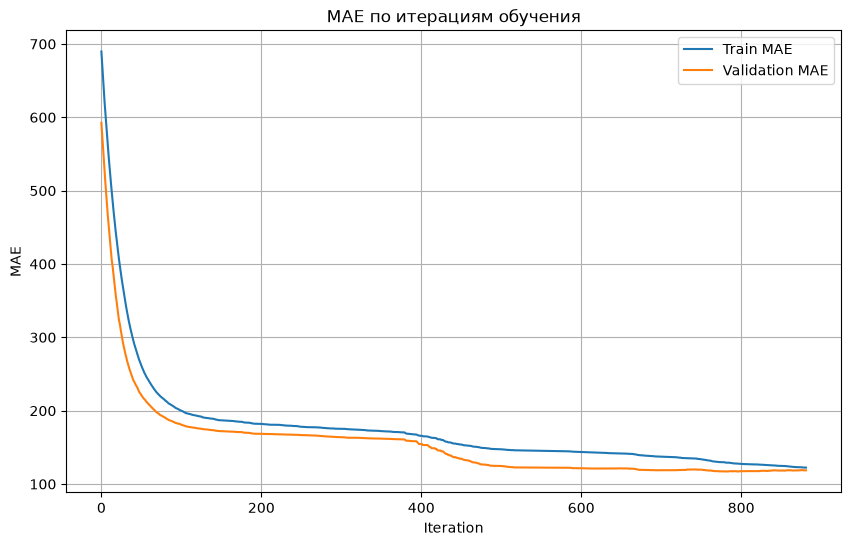

In [8]:
model = cb.CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function='MAE',
    verbose=100,
    cat_features=cat_features
)

model.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
    early_stopping_rounds=100,
    plot=False,
)

train_mae = model.get_evals_result()['learn']['MAE']
val_mae = model.get_evals_result()['validation']['MAE']

plt.figure(figsize=(10,6))
plt.plot(train_mae, label='Train MAE')
plt.plot(val_mae, label='Validation MAE')
plt.xlabel('Iteration')
plt.ylabel('MAE')
plt.title('MAE по итерациям обучения')
plt.legend()
plt.grid(True)

In [9]:
y_pred = np.clip(np.asarray(model.predict(X_test)).reshape(-1), 0, None)

print("опорная модель, оценка на сен-окт (горизонт 1-2 месяца вперёд)")
print(f"WAPE = {wape(y_test, y_pred):.4f}   WAPE-score = {wape_score(y_test, y_pred):.4f}")

display(wape_report(y_test, y_pred, X_test["route"], "route"))
display(wape_report(y_test, y_pred, X_test["hour"], "hour"))

опорная модель, оценка на сен-окт (горизонт 1-2 месяца вперёд)
WAPE = 0.2440   WAPE-score = 0.7560


route,y_sum,p_sum,err_sum,wape_local,wape_contrib,volume_share,bias
i32,f64,f64,f64,f64,f64,f64,f64
17,3.062882e6,2.2125e6,867987.230818,0.283389,0.068056,0.240151,-0.277637
50,1.157446e6,1.2333e6,442472.543038,0.382284,0.034693,0.090752,0.065541
7,1.350514e6,1.1330e6,338502.273757,0.250647,0.026541,0.10589,-0.161052
12,1.983521e6,1.7529e6,301980.123024,0.152244,0.023677,0.155522,-0.116253
11,1.906908e6,1.7483e6,271895.887164,0.142585,0.021319,0.149515,-0.083192
28,602163.0,794442.856326,208563.963275,0.346358,0.016353,0.047214,0.319315
25,464521.0,629901.805579,184028.269432,0.396168,0.014429,0.036422,0.356024
26,1.08991e6,1.1773e6,179878.197797,0.165039,0.014104,0.085457,0.080178
1,1.136093e6,1.1773e6,177963.471505,0.156645,0.013954,0.089078,0.036268


hour,y_sum,p_sum,err_sum,wape_local,wape_contrib,volume_share,bias
i8,f64,f64,f64,f64,f64,f64,f64
8,1.145598e6,943666.008233,278160.431282,0.242808,0.02181,0.089823,-0.176268
18,1.067295e6,901871.694194,266574.832125,0.249767,0.020901,0.083683,-0.154993
17,1.050353e6,897488.896556,248324.06506,0.23642,0.01947,0.082355,-0.145536
15,829031.0,739787.350703,203731.24563,0.245746,0.015974,0.065002,-0.107648
16,906936.0,804926.307792,202882.166065,0.223701,0.015907,0.07111,-0.112477
…,…,…,…,…,…,…,…
0,25039.0,28541.329078,11946.243871,0.477105,0.000937,0.001963,0.139875
4,2304.0,2722.910763,3744.028531,1.625012,0.000294,0.000181,0.181819
1,2410.0,3851.33227,3141.815981,1.303658,0.000246,0.000189,0.598063


## 5. Бэктест с реальным горизонтом

Обычный K-Fold здесь неприменим: прогноз строится на 61 день вперёд без единого факта
из целевого периода. Поэтому фолды - расширяющееся окно с горизонтом в два календарных
месяца, а `iterations` становится обычным подбираемым параметром: early stopping по
целевому периоду означал бы подбор числа деревьев по тем же данным, на которых мерится
качество.

In [10]:
# вся доступная история янв-окт, плотная сетка
all_df = pl.concat([train_df, test_df]).sort(["date", "hour", "route"])

FEATURE_SETS: dict[str, list[str]] = {
    "full": ["hour", "route", "is_holiday", "is_weekend", "is_short_working_day",
             "season", "weekday", "day_of_month", "day_of_year"],
    "no_doy": ["hour", "route", "is_holiday", "is_weekend", "is_short_working_day",
               "season", "weekday", "day_of_month"],
    "no_trend": ["hour", "route", "is_holiday", "is_weekend", "is_short_working_day",
                 "season", "weekday"],
    # циклические признаки: sin/cos кладут цикл на окружность, так что 23 час соседствует
    # с нулевым, а воскресенье с понедельником
    "cyclic": ["hour", "route", "is_holiday", "is_weekend", "is_short_working_day",
               "season", "weekday", "hour_sin", "hour_cos", "weekday_sin", "weekday_cos", "day_of_month_sin", "day_of_month_cos"],
    # то же плюс годовой цикл; ноя-дек в обучении не встречаются, поэтому эти два признака
    # лежат в невиданной области и проверяются отдельным набором, а не берутся по умолчанию
    "cyclic_year": ["hour", "route", "is_holiday", "is_weekend", "is_short_working_day",
                    "season", "weekday", "hour_sin", "hour_cos", "weekday_sin", "weekday_cos", "day_of_month_sin", "day_of_month_cos", "day_of_year_sin", "day_of_year_cos", "month_sin", "month_cos"],
}
CAT_FEATURES = ["route", "is_holiday", "is_weekend", "is_short_working_day", "season", "weekday"]

folds = make_folds(all_df)          # общие для всех трёх ноутбуков, из backtest.py
for f in folds:
    print(f.describe())


def recency_weights(dates, cut: date, half_life_days: float) -> np.ndarray:
    """вес наблюдения падает вдвое каждые half_life_days назад от края трейна"""
    if half_life_days <= 0 or not np.isfinite(half_life_days):
        return np.ones(len(dates), dtype=float)
    age = (np.datetime64(cut) - dates.to_numpy().astype("datetime64[D]")).astype("timedelta64[D]")
    return 0.5 ** (age.astype(float) / half_life_days)


def make_fns(params: dict, feature_set: str, half_life: float, seed: int = 0):
    """замыкания под интерфейс backtest.cv_score: fit_fn(train, cut) и predict_fn(model, df)"""
    feats = FEATURE_SETS[feature_set]
    cats = [c for c in CAT_FEATURES if c in feats]

    def fit_fn(trn: pl.DataFrame, cut: date):
        frame = trn.to_pandas()
        model = cb.CatBoostRegressor(
            **params, cat_features=cats, random_seed=seed, verbose=0, allow_writing_files=False,
        )
        model.fit(frame[feats], frame["target"], sample_weight=recency_weights(trn["date"], cut, half_life))
        return model

    def predict_fn(model, df: pl.DataFrame) -> np.ndarray:
        return np.clip(model.predict(df.to_pandas()[feats]), 0, None)

    return fit_fn, predict_fn


def cv_for(params: dict, feature_set: str, half_life: float, calibrate: bool = False, seed: int = 0):
    fit_fn, predict_fn = make_fns(params, feature_set, half_life, seed)
    return cv_score(fit_fn, predict_fn, folds, calibrate=calibrate)

край трейна 2025-04-30: train  28800 строк, valid 14640 строк (2025-05-01 - 2025-06-30)
край трейна 2025-06-30: train  43440 строк, valid 14880 строк (2025-07-01 - 2025-08-31)
край трейна 2025-08-31: train  58320 строк, valid 14640 строк (2025-09-01 - 2025-10-31)


In [ ]:
# калибровка: решаем по фолдам, а не по тому, насколько коэффициенты отличны от единицы.
# внутри фолда коэффициенты снимаются на периоде ПЕРЕД краем трейна - ровно та схема,
# что уходит в сабмит
BASE_PARAMS = {
    "loss_function": "MAE", "thread_count": -1, "bootstrap_type": "Bayesian",
    "iterations": 3000, "learning_rate": 0.03, "depth": 8,
}

mean_off, per_fold_off, _ = cv_for(BASE_PARAMS, "full", float("inf"), calibrate=False)
mean_on, per_fold_on, details = cv_for(BASE_PARAMS, "full", float("inf"), calibrate=True)

print(f"без калибровки: CV WAPE = {mean_off:.4f}  {[round(s, 4) for s in per_fold_off]}")
print(f"с калибровкой:  CV WAPE = {mean_on:.4f}  {[round(s, 4) for s in per_fold_on]}")
for d in details:
    ks = d["calibration"]
    print(f"   фолд {d['cut']}: k от {min(ks.values()):.3f} до {max(ks.values()):.3f}")

USE_CALIBRATION = mean_on < mean_off
print(f"\nкалибровка {'включена' if USE_CALIBRATION else 'выключена'} - решение по фолдам")

## 6. Подбор гиперпараметров

Трайл 0 - текущий бейзлайн, чтобы в таблице было видно, что даёт подбор относительно него.
40 трайлов x 3 фолда - порядка 15-40 минут на 10 ядрах; для пробного прогона поставь
`N_TRIALS = 10`.

In [12]:
import json
from pathlib import Path

import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 10
FIXED = {"thread_count": -1, "bootstrap_type": "Bayesian"}


def suggest(trial) -> tuple[dict, str, float]:
    # Quantile:alpha=0.5 эквивалентен MAE и согласован с WAPE;
    # сдвиг alpha вверх лечит системный недобор на пиках
    alpha = trial.suggest_float("alpha", 0.45, 0.60, step=0.01)
    params = {
        **FIXED,
        "loss_function": f"Quantile:alpha={alpha:.2f}",
        "iterations": trial.suggest_int("iterations", 500, 6000, step=250),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth": trial.suggest_int("depth", 5, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.5, 30.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 3.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "one_hot_max_size": trial.suggest_categorical("one_hot_max_size", [2, 16, 64]),
    }
    feature_set = trial.suggest_categorical("feature_set", list(FEATURE_SETS))
    half_life = trial.suggest_categorical("half_life", [30.0, 60.0, 120.0, float("inf")])
    return params, feature_set, half_life


def objective(trial) -> float:
    params, feature_set, half_life = suggest(trial)
    mean_wape, per_fold, _ = cv_for(params, feature_set, half_life, calibrate=USE_CALIBRATION)
    for i, s in enumerate(per_fold):
        trial.set_user_attr(f"fold{i}_wape", s)
    return mean_wape


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=15),
    study_name="catboost_wape",
)

study.enqueue_trial({
    "alpha": 0.50, "iterations": 3000, "learning_rate": 0.03, "depth": 8,
    "l2_leaf_reg": 3.0, "min_data_in_leaf": 1, "random_strength": 1.0,
    "bagging_temperature": 1.0, "one_hot_max_size": 2,
    "feature_set": "full", "half_life": float("inf"),
})

study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)

best = study.best_trial
print(f"CV WAPE = {best.value:.4f}  ->  WAPE-score = {max(0.0, 1 - best.value):.4f}")
print("по фолдам:", {k: round(v, 4) for k, v in best.user_attrs.items()})
print(json.dumps(best.params, indent=2, ensure_ascii=False))

display(
    study.trials_dataframe(attrs=("number", "value", "user_attrs", "params"))
    .sort_values("value")
    .head(10)
)

  0%|          | 0/10 [00:00<?, ?it/s]

CV WAPE = 0.1557  ->  WAPE-score = 0.8443
по фолдам: {'fold0_wape': 0.1455, 'fold1_wape': 0.1926, 'fold2_wape': 0.1289}
{
  "alpha": 0.49,
  "iterations": 500,
  "learning_rate": 0.05210786568543147,
  "depth": 8,
  "l2_leaf_reg": 0.6173152563090734,
  "min_data_in_leaf": 2,
  "random_strength": 2.724797657899961,
  "bagging_temperature": 0.47912378133394484,
  "one_hot_max_size": 64,
  "feature_set": "no_trend",
  "half_life": 60.0
}


,number,value,user_attrs_fold0_wape,user_attrs_fold1_wape,user_attrs_fold2_wape,params_alpha,params_bagging_temperature,params_depth,params_feature_set,params_half_life,params_iterations,params_l2_leaf_reg,params_learning_rate,params_min_data_in_leaf,params_one_hot_max_size,params_random_strength
9,9,0.155678,0.145540,0.192571,0.128924,0.49,0.479124,8,no_trend,60.0,500,0.617315,0.052108,2,64,2.724798
3,3,0.157418,0.144657,0.197118,0.130479,0.49,1.818641,7,no_doy,30.0,1000,0.824086,0.063785,7,16,0.103166
2,2,0.162545,0.151041,0.206038,0.130556,0.51,1.570352,5,no_doy,120.0,2000,1.653664,0.052432,3,64,1.368210
0,0,0.176445,0.180968,0.175108,0.173260,0.50,1.000000,8,full,inf,3000,3.000000,0.030000,1,2,1.000000
5,5,0.179684,0.146618,0.184341,0.208094,0.45,0.231738,9,no_trend,120.0,5000,11.759946,0.067815,1,2,1.075397
6,6,0.180525,0.206296,0.171269,0.164010,0.46,0.855082,8,full,30.0,4500,11.745358,0.078479,7,16,1.568198
1,1,0.183096,0.210512,0.165922,0.172855,0.50,1.732352,8,full,inf,5750,0.947098,0.072592,1,16,0.174251
4,4,0.186255,0.165485,0.212808,0.180473,0.54,0.542698,6,no_trend,60.0,5750,0.601715,0.012708,3,2,1.166032
8,8,0.189569,0.167285,0.218294,0.183127,0.58,0.675230,8,no_trend,30.0,5250,2.761785,0.010190,2,2,0.359596
7,7,0.200572,0.177138,0.239579,0.185000,0.48,1.742921,5,no_trend,inf,750,22.496401,0.021917,36,64,1.900211


Смотреть не только на средний WAPE, но и на разброс по фолдам. Первый фолд хуже остальных -
это нормально, истории меньше. А вот если лучший трайл выигрывает только на одном фолде -
брать его нельзя, это подгонка.

## 7. Финальная модель

Калибровочные коэффициенты снимаются с последнего фолда: модель там обучена по 31 августа,
факт сен-окт для неё вне обучения. Сама финальная модель обучается на всей истории янв-окт.

In [ ]:
best_params, best_fs, best_hl = suggest(optuna.trial.FixedTrial(best.params))

# 1. калибровка, если бэктест сказал, что она помогает
calib: dict[int, float] = {}
if USE_CALIBRATION:
    last = folds[-1]
    inner_fit, inner_predict = make_fns(best_params, best_fs, best_hl)
    inner = inner_fit(last.calib_train, last.calib_cut)
    calib = fit_calibration(
        last.calib_valid["target"], inner_predict(inner, last.calib_valid), last.calib_valid["route"],
    )
    print(f"калибровка: { {r: round(k, 3) for r, k in calib.items()} }")
else:
    print("калибровка выключена по результатам бэктеста")

# 2. финальная модель на всей истории янв-окт
iters_scale = all_df.height / folds[-1].train.height      # данных больше - деревьев чуть больше
final_params = {**best_params, "iterations": int(best_params["iterations"] * iters_scale)}
final_fit, final_predict = make_fns(final_params, best_fs, best_hl)
final_model = final_fit(all_df, date(2025, 10, 31))
final_feats = FEATURE_SETS[best_fs]
print(f"\nфинальная модель: {all_df.height} строк, {final_params['iterations']} итераций, набор фич {best_fs}")

# 3. артефакты для сдачи
ART = Path("artifacts/catboost")
ART.mkdir(parents=True, exist_ok=True)
final_model.save_model(ART / "model.cbm")
with open(ART / "model_meta.json", "w", encoding="utf-8") as f:
    json.dump({
        "model": "CatBoost on calendar features",
        "params": final_params,
        "feature_set": best_fs,
        "features": final_feats,
        "cat_features": [c for c in CAT_FEATURES if c in final_feats],
        "half_life_days": None if best_hl == float("inf") else best_hl,
        "routes": list(ROUTES),
        "train_period": ["2025-01-01", "2025-10-31"],
        "cv_wape": best.value,
        "cv_per_fold": dict(best.user_attrs),
        "use_calibration": bool(USE_CALIBRATION),
        "route_calibration": calib,
        "dead_route_hour_pairs": dead_keys.to_pandas().to_dict(orient="records"),
    }, f, indent=2, ensure_ascii=False)
print(f"сохранено в {ART}")

display(
    pl.DataFrame({"feature": final_feats, "importance": final_model.get_feature_importance()})
    .sort("importance", descending=True)
)

фолд 3, WAPE без калибровки: 0.1289
фолд 3, WAPE с калибровкой:  0.1250  (оптимистично: k подобран на этом же периоде)
коэффициенты: {1: 1.042, 5: 1.0, 7: 0.962, 11: 1.039, 12: 1.03, 17: 1.064, 25: 1.18, 26: 1.072, 28: 1.025, 50: 0.906}
максимальное отклонение 18.0% -> калибровка включена

финальная модель: 72960 строк, 625 итераций, набор фич no_trend


feature,importance
str,f64
"""route""",45.492708
"""hour""",43.129604
"""is_weekend""",9.295691
"""season""",1.303302
"""weekday""",0.757124
"""is_holiday""",0.015241
"""is_short_working_day""",0.006329


## 8. Submission

In [ ]:
from datetime import datetime

SUBMIT_DIR = Path("artifacts/submissions")
SUBMIT_DIR.mkdir(parents=True, exist_ok=True)
SUBMIT_PATH = SUBMIT_DIR / f"submission_catboost_{datetime.now().strftime('%m-%d-%Y_%H:%M:%S')}.csv"

submit_sorted = submit_df.sort(["date", "hour", "route"])
pred = final_predict(final_model, submit_sorted)
if USE_CALIBRATION:
    pred = apply_calibration(pred, submit_sorted["route"], calib)

# мёртвые пары route x hour зануляем
dead = set(map(tuple, dead_keys.to_pandas().to_numpy()))
alive = np.array([(r, h) not in dead for r, h in zip(submit_sorted["route"].to_numpy(), submit_sorted["hour"].to_numpy())])
pred = np.where(alive, pred, 0.0)
print(f"занулено строк: {(~alive).sum()} из {len(alive)}")

submission = (
    pl.DataFrame({
        "route": submit_sorted["route"], "date": submit_sorted["date_str"],
        "hour": submit_sorted["hour"], "prediction": pred,
    })
    .with_columns(
        pl.col("route").cast(pl.Int32), pl.col("hour").cast(pl.Int32),
        pl.col("prediction").round(0).cast(pl.Int64),
    )
    .sort(["route", "date", "hour"])
)

expected_height = len(ROUTES) * 61 * 24
assert submission.height == expected_height, f"ожидалось {expected_height} строк, получено {submission.height}"
assert set(submission["route"].unique().to_list()) == set(ROUTES), "не все маршруты в сетке"
assert submission["date"].n_unique() == 61, "не все даты ноя-дек"
assert submission.select(pl.all().is_null().any()).row(0) == (False,) * 4, "есть пропуски"
assert submission["prediction"].min() >= 0, "есть отрицательные прогнозы"
assert submission.select(pl.struct(["route", "date", "hour"]).n_unique()).item() == submission.height, "дубли ключей"

submission.write_csv(SUBMIT_PATH, separator=";")
print(f"записано {submission.height} строк в {SUBMIT_PATH}")

print("\nнакопленные submission:")
for f in sorted(SUBMIT_DIR.glob("submission_*.csv")):
    mark = " <- текущий" if f == SUBMIT_PATH else ""
    print(f"  {f.name}  {f.stat().st_size / 1024:.0f} КБ{mark}")

display(all_df.group_by(pl.col("date").dt.month().alias("month")).agg(pl.col("target").sum().alias("факт")).sort("month").tail(3))
display(
    submission.with_columns(pl.col("date").str.to_date().dt.month().alias("month"))
    .group_by("month").agg(pl.col("prediction").sum().alias("прогноз")).sort("month")
)
print(f"итоговая сумма прогноза: {submission['prediction'].sum():,}")

занулено строк: 1586 из 14640
записано 14640 строк в artifacts/submissions/submission_09-25-2026_19:53:23.csv

накопленные submission:
  submission_09-25-2026_19:53:23.csv  286 КБ <- текущий


month,факт
i8,i32
8,5309977
9,6147171
10,6606787


month,прогноз
i8,i64
11,6055701
12,6539361


route,прогноз
i32,i64
5,0
25,494811
28,609634
50,1035726
26,1104034
1,1124915
7,1270046
11,1899681
12,1956815


итоговая сумма прогноза: 12,595,062


Если сумма по ноябрю или декабрю сильно ниже октябрьского факта (6.6 млн) - это упомянутая
экстраполяция: все дни горизонта легли в последний лист по `day_of_year`. Смотри, какой
`feature_set` выбрал подбор, и сравни с `no_doy`.

## Что дальше

Дальше метрику двигают фичи, а не гиперпараметры:

1. Погода (`weather/data`, факт ERA5 за ноя-дек 2025 разрешён правилами) и длина светового дня -
   они переносят ноя-дек в уже виденную моделью область признаков, в отличие от `day_of_year`.
2. Профильные агрегаты: медиана по `route x тип дня x weekday x hour` за трейлинг 4/8/12 недель,
   считается по данным до 31 октября и остаётся валидной на всём горизонте. Для обучающих строк
   считать причинно, окном строго до даты строки.
3. Календарь события: школьные каникулы (осенние до 4 ноября, зимние с 27 декабря), расстояние
   до праздничного блока, отдельный флаг 31 декабря - в производственном календаре это рабочий
   день, а по факту провал. Аналог в данных есть: 1-8 января, ~110 тыс. в день против 240 тыс.
4. Аномалии: у маршрута 7 в июле-августе 403 и 472 тыс. против ~700 тыс. в остальные месяцы,
   это похоже на закрытие пути, а не на сезонность. Такие периоды надо помечать или исключать.
5. Двухступенчатая декомпозиция: дневной уровень по маршруту x нормированный почасовой профиль.
   Форма суток тогда гарантированно верна, а уровень калибруется отдельно.

Новые варианты фич добавляются в `FEATURE_SETS` - подбор сам их сравнит.

## 9. Прогнозы для ансамбля

Веса смеси подбираются по этим файлам - на фолдах, а не на цели. Те же ячейки есть в
`harmonic_baseline.ipynb` и `mlp_baseline.ipynb`, смесь собирает `blend.py`.

In [ ]:
PRED_DIR = Path("artifacts/preds")
PRED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_TAG = "catboost"

for i, fold in enumerate(folds):
    fitted = final_fit(fold.train, fold.cut)
    (
        fold.valid.select(["date", "hour", "route", "target"])
        .with_columns(pl.Series("pred", final_predict(fitted, fold.valid)))
        .write_parquet(PRED_DIR / f"{MODEL_TAG}_fold{i}.parquet")
    )

submission.with_columns(pl.col("date").str.to_date()).rename({"prediction": "pred"}).write_parquet(
    PRED_DIR / f"{MODEL_TAG}_submit.parquet"
)

for f in sorted(PRED_DIR.glob("*.parquet")):
    print(f"  {f.name}  {f.stat().st_size / 1024:.0f} КБ")